Loading BokehJS ...

Loaded 'examples_audio/Dufour_full_mono.aif' -> 77.67s @ 44100Hz
Detected onset times (s): [ 0.151  2.749  4.859  7.082  9.462 11.546 13.767 15.993 18.373 20.477
 22.837 23.438 24.036 24.471 24.95  25.086 25.681 26.259 26.7   27.173
 27.304 27.905 28.505 28.947 29.42  29.553 30.151 30.726 31.158 31.64
 31.771 32.372 32.972 33.408 33.887 34.02  34.618 35.193 35.628 36.127
 36.261 36.865 37.462 37.904 38.377 38.51  39.108 39.686 40.121 40.6
 40.731 41.332 41.929 42.371 42.844 42.977 43.575 44.153 44.585 45.067
 45.195 45.798 46.396 46.829 47.311 47.438 48.042 48.62  49.052 49.534
 49.662 50.262 50.863 51.302 51.778 51.905 52.509 53.084 53.525 53.998
 54.132 54.181 54.729 55.33  55.769 56.242 56.372 56.973 57.551 57.992
 58.465 58.598 59.196 59.794 60.235 60.691 60.822 61.42  62.018 62.459
 62.932 63.065 63.663 64.241 64.676 65.155 65.286 65.887 66.485 66.926
 67.399 67.527 68.13  68.705 69.14  69.619 69.75  69.802]


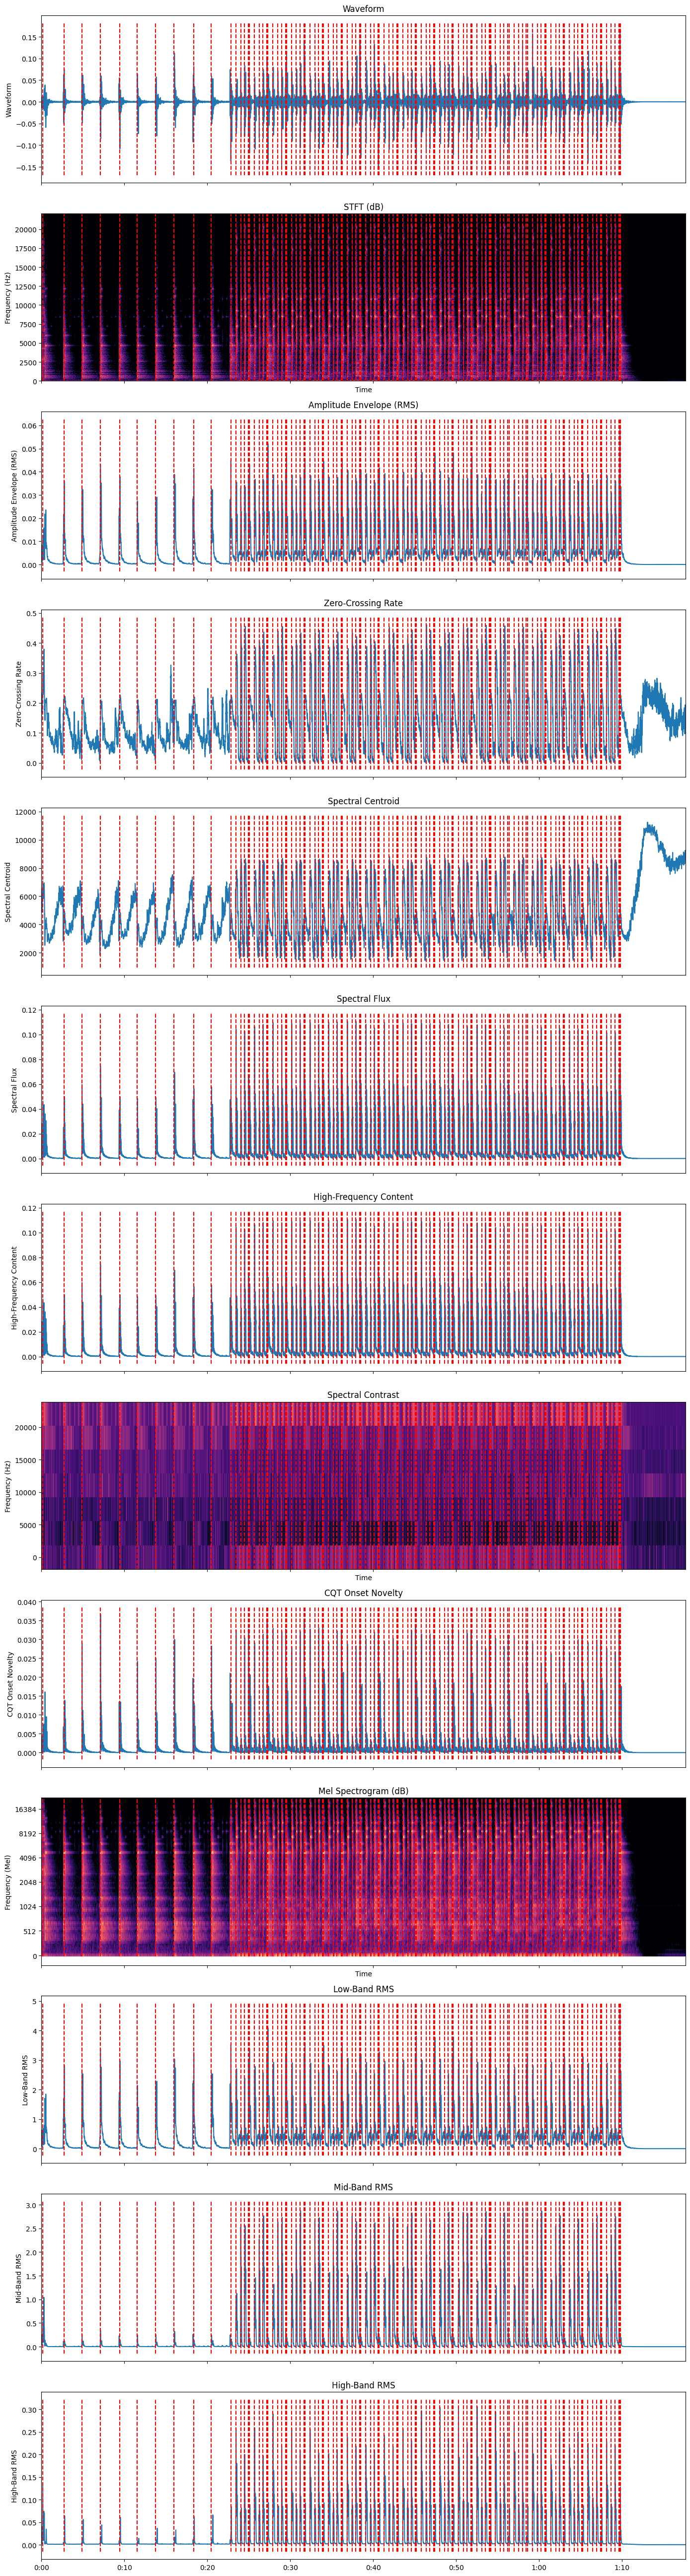

In [6]:
# Import the functions from your updated module
from py_scripts.audio_visualizer import load_audio, extract_features, detect_onsets, visualize_features
import numpy as np

# --- BOKEH SETUP ---
# Import the necessary function to configure Bokeh for inline notebook display
from bokeh.io import output_notebook

# Call this function ONCE at the start of your script to enable inline plotting
output_notebook()
# --- END BOKEH SETUP ---


# --- CONFIGURATION ---
AUDIO_PATH = 'examples_audio/Dufour_full_mono.aif'
HOP_LENGTH = 128
N_FFT = 2048

# Features: 'waveform', 'stft_db', 'spec_db', 'amplitude_envelope', 'zero_crossing_rate', 
# 'spectral_centroid', 'spectral_flux', 'high_frequency_content', 'spectral_contrast', 'cqt_flux', 
# 'melspectrogram', 'rms_low', 'rms_mid', 'rms_high'

FEATURES_TO_PLOT = [
    'waveform', 'stft_db', 'amplitude_envelope', 'zero_crossing_rate', 
    'spectral_centroid', 'spectral_flux', 'high_frequency_content', 'spectral_contrast', 'cqt_flux', 
    'melspectrogram', 'rms_low', 'rms_mid', 'rms_high'
]

# Set the backend for the inline display: 'matplotlib' or 'bokeh'
PLOTTING_BACKEND = 'matplotlib'

ONSET_PARAMS = {
    'delta': 0.3,
    'backtrack': True
}

# --- SCRIPT EXECUTION ---

# 1. Load the audio file
y, sr = load_audio(AUDIO_PATH)

# 2. Extract all necessary features at once
features = extract_features(y, sr, hop_length=HOP_LENGTH, n_fft=N_FFT)

# 3. Detect onsets
onset_times = detect_onsets(y, sr, hop_length=HOP_LENGTH, **ONSET_PARAMS)
print('Detected onset times (s):', np.round(onset_times, 3))

# 4. Visualize the features and onsets
visualize_features(
    features=features,
    sr=sr,
    hop_length=HOP_LENGTH,
    onset_times=onset_times,
    features_to_plot=FEATURES_TO_PLOT,
    backend=PLOTTING_BACKEND
)

In [7]:
from py_scripts.onset_pattern_filter import filter_onset_patterns
import numpy as np

# You already have onset_times from your previous cell
# Single-interval example:
single_seqs = filter_onset_patterns(onset_times, pattern=2.23, tolerance=0.25)
print("Single-interval matches (sequence, score):")
for seq, score in single_seqs:
    print(f"Score: {score:.5f}\nSequence: {np.round(seq, 3)}\n")

# Repeating-pattern example:
pattern = [0.5, 1.0, 0.75]
pattern_seqs = filter_onset_patterns(onset_times, pattern=pattern, tolerance=0.05)
print("Pattern-based matches (sequence, score):")
for seq, score in pattern_seqs:
    print(f"Score: {score:.5f}\nSequence: {np.round(seq, 3)}\n")


Single-interval matches (sequence, score):
Score: 0.00433
Sequence: [ 2.749  4.859  7.082  9.462 11.546 13.767 15.993 18.373 20.477 22.837
 24.95  27.173 29.42  31.64  33.887 36.127 38.377 40.6   42.844 45.067
 47.311 49.534 51.778 53.998 56.242 58.465 60.691 62.932 65.155 67.399
 69.619]

Pattern-based matches (sequence, score):
Score: 0.18659
Sequence: [23.438 24.471 24.95  25.681 26.7   27.173 27.905 28.947 29.42  30.151
 31.158 31.64  32.372 33.408 33.887 34.618 35.628 36.127 36.865 37.904
 38.377 39.108 40.121 40.6   41.332 42.371 42.844 43.575 44.585 45.067
 45.798 46.829 47.311 48.042 49.052 49.534 50.262 51.302 51.778 52.509
 53.525 53.998 54.729 55.769 56.242 56.973 57.992 58.465 59.196 60.235
 60.691 61.42  62.459 62.932 63.663 64.676 65.155 65.887 66.926 67.399
 68.13  69.14  69.619]



In [8]:
# Take the best (first) sequence:
best_seq, best_score = single_seqs[0]

print(f"Best fit score: {best_score:.5f}")
print("Onset times in best sequence:", best_seq)


Best fit score: 0.00433
Onset times in best sequence: [ 2.74866213  4.85877551  7.08208617  9.46213152 11.54612245 13.76653061
 15.99274376 18.37278912 20.47709751 22.8368254  24.94984127 27.17315193
 29.41968254 31.6400907  33.88662132 36.12734694 38.37678005 40.6000907
 42.84371882 45.06702948 47.3106576  49.53396825 51.77759637 53.99800454
 56.24163265 58.46494331 60.69115646 62.93188209 65.15519274 67.39882086
 69.61922902]


In [9]:
# # Save selected sequence as CSV

# import os

# # 1. Define the filename
# filename = "best_sequence.csv"

# # 2. Save the array to the CSV file
# np.savetxt(filename, best_seq, delimiter=",")

# # 3. Get the full, absolute path of the file
# full_path = os.path.abspath(filename)

# # 4. Print the confirmation message with the full path
# print(f"The best sequence has been saved to: {full_path}")

The best sequence has been saved to: c:\Users\egorp\Nextcloud\code\public_repos\beat_it\best_sequence.csv


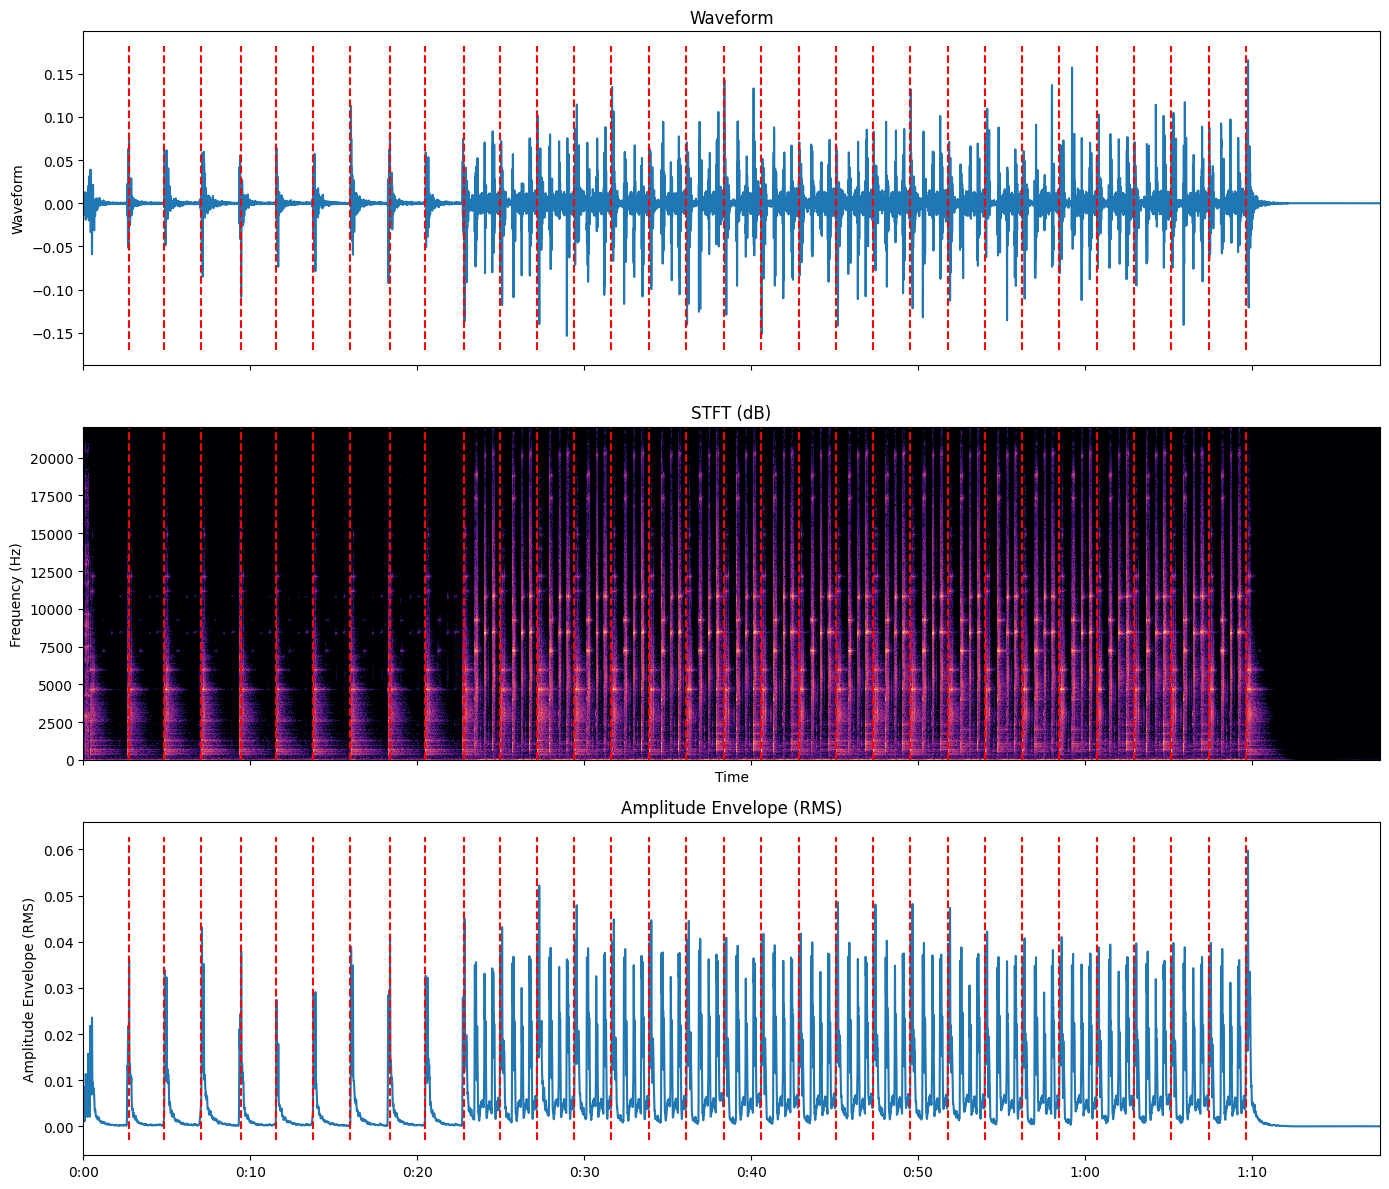

In [12]:
from py_scripts.audio_visualizer import visualize_features

# Pick out the best‐fitting onset times:
best_seq, best_score = single_seqs[0]

# Tell visualize_features which features you want to see:
FEATURES_TO_PLOT = ['waveform', 'stft_db', 'amplitude_envelope']

# Plot it (use matplotlib or bokeh)
visualize_features(
    features=features,
    sr=sr,
    hop_length=HOP_LENGTH,
    onset_times=best_seq,               # <-- your filtered times here
    features_to_plot=FEATURES_TO_PLOT,
    backend='matplotlib'            
)
